IP to Country Geolocation Mapping

Load Data

In [2]:
import pandas as pd
import numpy as np

fraud = pd.read_csv("../data/raw/Fraud_Data.csv")
geo = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

Convert IP to Integer

In [3]:
fraud["ip_int"] = fraud["ip_address"].astype(float).astype(int)

Prepare Geo Ranges

In [4]:
geo["lower_bound_ip_address"] = geo["lower_bound_ip_address"].astype(float).astype(int)
geo["upper_bound_ip_address"] = geo["upper_bound_ip_address"].astype(float).astype(int)

Range Merge

In [5]:
fraud = fraud.sort_values("ip_int")
geo = geo.sort_values("lower_bound_ip_address")

merged = pd.merge_asof(
    fraud,
    geo,
    left_on="ip_int",
    right_on="lower_bound_ip_address",
    direction="backward"
)

merged = merged[merged["ip_int"] <= merged["upper_bound_ip_address"]]

Country Fraud Analysis

<Axes: xlabel='country'>

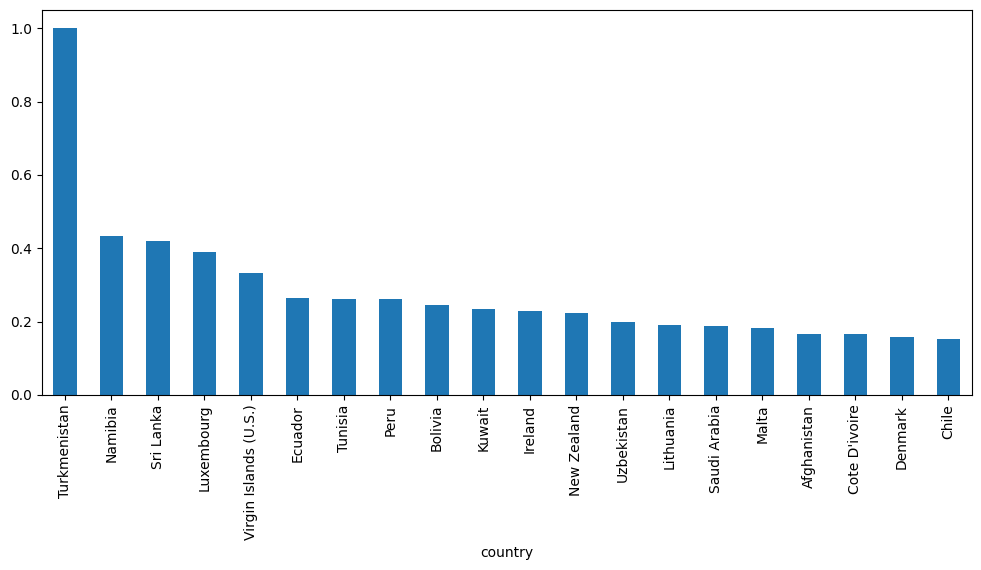

In [6]:
country_fraud = merged.groupby("country")["class"].mean().sort_values(ascending=False)

country_fraud.head(20).plot(kind="bar", figsize=(12,5))

Save

In [8]:
merged.to_csv("../data/raw/processed/fraud_geo.csv", index=False)